***Hg Wavelength Calibration***

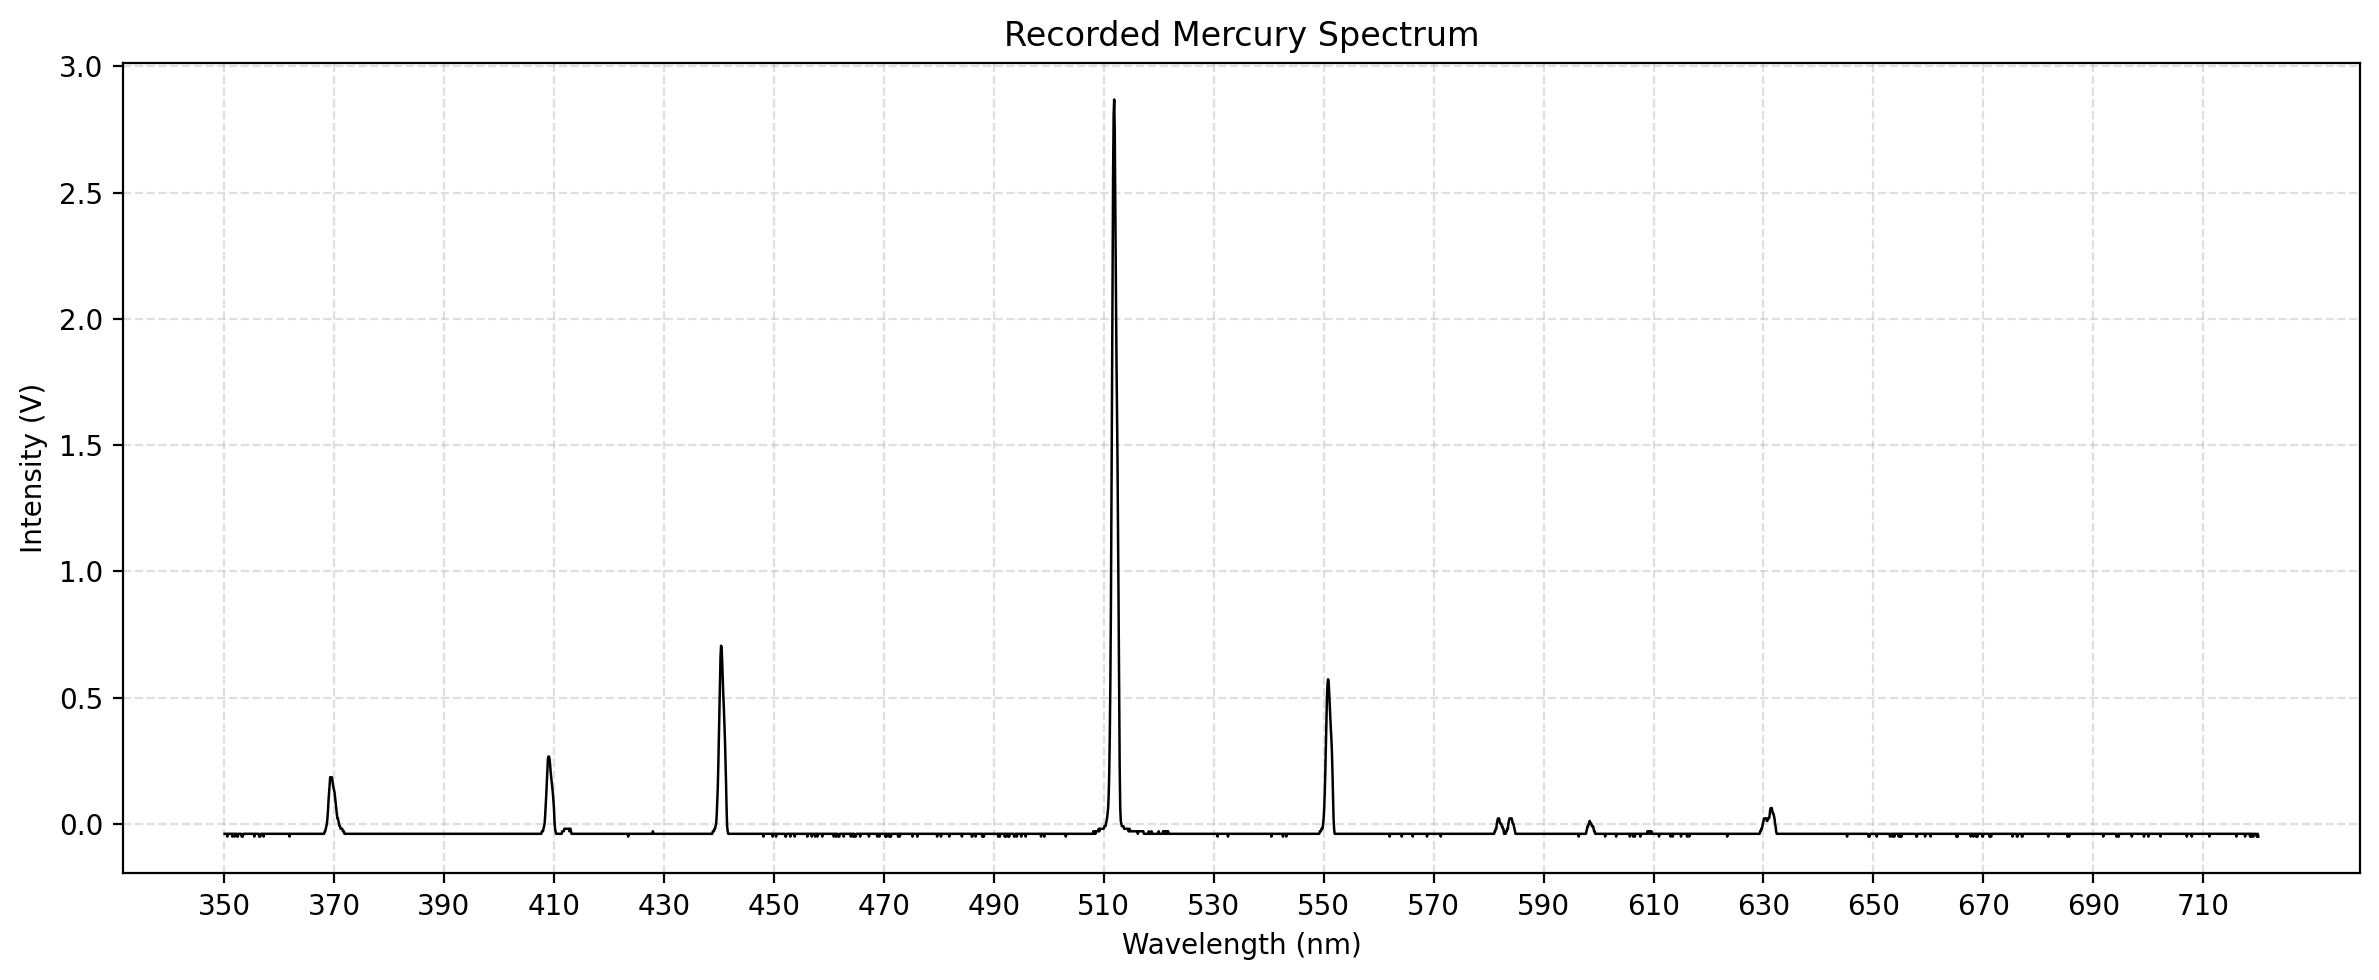

In [2]:
import numpy as np
import matplotlib.pyplot as plt

fname = "15Uhr03_FP_Ba11_Hg_Spectrum_50mV.dat"

# ----------- read file -----------
with open(fname, "r", encoding="utf-8") as f:
    lines = f.readlines()

# ----------- metadata -----------
start_wavelength = float(lines[0].strip().replace(",", "."))  # e.g. 720 nm
gear_factor      = float(lines[1].strip().replace(",", "."))  # = nm/s
direction        = int(lines[2].strip())                      # +1 or -1

# ----------- data -----------
data = []
for line in lines[3:]:
    line = line.strip()
    if not line:
        continue
    line = line.replace(",", ".")
    parts = line.split()
    if len(parts) == 2:
        t, I = map(float, parts)
        data.append([t, I])

data = np.array(data)
t = data[:, 0]
I = -data[:, 1]           # flip sign so peaks point upward

# ----------- wavelength axis -----------
nm_per_s = gear_factor    # ***correct: directly nm/s***

if direction == 1:
    wl_raw = start_wavelength + nm_per_s * t
else:
    wl_raw = start_wavelength - nm_per_s * t

# we want wavelength increasing left → right
if wl_raw[0] > wl_raw[-1]:
    wavelength = wl_raw[::-1]
    intensity  = I[::-1]
else:
    wavelength = wl_raw
    intensity  = I

# ----------- plot -----------
plt.figure(figsize=(12, 5), dpi=200)
plt.plot(wavelength, intensity, linewidth=0.9, color="black")

plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity (V)")
plt.title("Recorded Mercury Spectrum")

xmin = np.floor(wavelength.min() / 25) * 25
xmax = np.ceil(wavelength.max() / 25) * 25
plt.xticks(np.arange(xmin, xmax + 1, 20))

plt.grid(alpha=0.4, linestyle="--")
plt.tight_layout()
plt.show()


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# Known Hg reference lines (nm), using only visible lines for calibration
hg_true = np.array([365.0, 404.7, 435.8, 546.1, 577.0, 579.0])

# ----------------------------------------------------
# Function to find calibration shift
# ----------------------------------------------------
def compute_wavelength_shift(filename):
    wav, I = load_spectrum(filename)   # your existing loader

    # --- Peak detection ---
    # find local maxima
    peaks, _ = find_peaks(I, prominence=0.01)  # adjust if needed

    peak_wav = wav[peaks]
    peak_I = I[peaks]

    # --- Remove the giant 253.7 nm first-order peak (~512 nm) ---
    artifact_mask = peak_wav < 520   # everything >520 is real long-wavelength lines
    peak_wav = peak_wav[artifact_mask]
    peak_I = peak_I[artifact_mask]

    # Sort by wavelength
    order = np.argsort(peak_wav)
    peak_wav = peak_wav[order]

    # We expect exactly 6 real peaks
    peak_wav = peak_wav[-6:]   # keep the highest 6 peaks below 520 nm

    print("Measured peak wavelengths (nm):", peak_wav)

    # Compute shift = true – measured
    shifts = hg_true - peak_wav
    shift_mean = np.mean(shifts)

    print("Individual shifts:", shifts)
    print(f"Estimated wavelength offset = {shift_mean:.3f} nm")

    return shift_mean, peak_wav, peaks


# ----------------------------------------------------
# Example run on your Hg file
# ----------------------------------------------------
shift, peak_wavs, peak_indices = compute_wavelength_shift("15Uhr03_FP_Ba11_Hg_Spectrum.dat")

# ----------------------------------------------------
# Example: apply this calibration to any spectrum
# ----------------------------------------------------
def apply_calibration(wavelength):
    return wavelength + shift


NameError: name 'load_spectrum' is not defined